# 注意力的显存难题，和一个聪明的解法

注意力机制的核心，其实就一行公式：

$$O = \operatorname{softmax}\!\left(\frac{QK^\top}{\sqrt{d}}\right)V$$

短序列下它人畜无害。可一旦序列变长，这行公式会悄悄吃掉**几十 GB 显存**，直接把训练撑爆。

这一篇我们不急着上 GPU kernel，而是先用最朴素的 PyTorch 把注意力算一遍，亲手撞上那堵"显存墙"，
然后**自己把解法推导出来**——它有个名字叫 *online softmax*，正是下一章 FlashAttention 的算法内核。

读完你会明白三件事：显存为什么会炸、softmax 凭什么能分块算、以及——为什么光有好算法还不够。

先把工具准备好：


In [1]:
import sys, math
from pathlib import Path

import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

# 把仓库根与本章目录加入路径，方便 import common / vanilla
ROOT = Path.cwd()
while not (ROOT / "common").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / "01-vanilla-attention"))

from common import naive_attention, assert_close, make_qkv, bench_ms, peak_memory_mb
from vanilla import online_softmax_attention

torch.manual_seed(0)
print("跑在", torch.cuda.get_device_name(0), "| PyTorch", torch.__version__)


跑在 NVIDIA GeForce RTX 4090 | PyTorch 2.13.0.dev20260502+cu132


## 先老老实实算一遍

优化之前，得先看清楚自己在算什么。我们拿一个迷你的例子——1 个样本、1 个注意力头、
**4 个 token**、每个 token 用 4 维向量表示——把注意力一步步算出来，把中间结果都打印看看。

公式拆成三步：先 $Q$ 和 $K$ 两两点积得到一张"谁该关注谁"的打分表，再按行 softmax 成概率，
最后用这些概率去加权平均 $V$。


In [2]:
q, k, v = make_qkv(1, 1, 4, 4, dtype=torch.float32, seed=1)
scale = 1.0 / math.sqrt(q.shape[-1])

scores = (q @ k.transpose(-1, -2)) * scale   # 第 1 步：QKᵀ/√d，每个 query 对每个 key 打分
attn   = torch.softmax(scores, dim=-1)        # 第 2 步：按行归一化成概率
out    = attn @ v                             # 第 3 步：用概率加权平均 V

print("打分表 scores（4 个 query × 4 个 key）：")
print(scores[0, 0])
print("\nsoftmax 之后（每一行是一组和为 1 的概率）：")
print(attn[0, 0])
print("每行之和 =", attn[0, 0].sum(-1).tolist(), "← 确实都是 1")


打分表 scores（4 个 query × 4 个 key）：
tensor([[-0.1108, -0.4158, -1.1556, -0.5198],
        [-1.2517, -0.3301,  1.2301,  2.4767],
        [ 0.5141,  0.6767,  0.9969,  0.5517],
        [ 1.8986,  0.8714, -1.0885, -1.2764]], device='cuda:0')

softmax 之后（每一行是一组和为 1 的概率）：
tensor([[0.3632, 0.2677, 0.1278, 0.2413],
        [0.0175, 0.0440, 0.2095, 0.7289],
        [0.2068, 0.2433, 0.3352, 0.2147],
        [0.6895, 0.2469, 0.0348, 0.0288]], device='cuda:0')
每行之和 = [1.0, 0.9999999403953552, 1.0, 1.0] ← 确实都是 1


## 等一下，注意到那张方阵了吗？

打分表 `scores` 的形状是 **(query 数 × key 数)**。这里是 4×4，无所谓。

但 query 和 key 的数量都等于序列长度 $S$。也就是说，这张表的大小是 $S \times S$——
**序列翻一倍，它就翻四倍**。序列到了几千、上万，这张中间表本身就是个庞然大物。

别光听我说，我们让数字说话：换几个序列长度，量一量朴素实现的峰值显存。


In [3]:
print(f"{'序列长度':>8} {'峰值显存':>12}   注意力方阵本身的大小")
for S in [512, 1024, 2048, 4096]:
    q, k, v = make_qkv(4, 16, S, 64, dtype=torch.float16, seed=0)
    torch.cuda.reset_peak_memory_stats()
    _ = naive_attention(q, k, v, causal=True)
    mb = peak_memory_mb()
    matrix_mb = 4 * 16 * S * S * 4 / 1024**2   # batch*heads*S*S*float32
    print(f"{S:>8} {mb:>10.0f} MB   {matrix_mb:>8.0f} MB")
    del q, k, v; torch.cuda.empty_cache()

print("\n序列长度涨 8 倍（512→4096），显存涨了约 64 倍——这就是 O(S²) 的代价。")


    序列长度         峰值显存   注意力方阵本身的大小


     512        164 MB         64 MB
    1024        581 MB        256 MB
    2048       2180 MB       1024 MB
    4096       8456 MB       4096 MB



序列长度涨 8 倍（512→4096），显存涨了约 64 倍——这就是 O(S²) 的代价。


## 那……能不能干脆不算出这张方阵？

问题出在我们"一口气"构造了完整的 $S\times S$ 打分表。如果能**一次只看一小块 key**、
算完就扔、不保留整张表，显存不就降下来了吗？

听上去美好，但 softmax 挡在路上。回忆它的定义：

$$\operatorname{softmax}(x)_i = \frac{e^{x_i}}{\sum_j e^{x_j}}$$

那个分母要**对所有 key 求和**。你不把所有 key 看完，怎么知道总和？这就是分块的障碍。

要绕过它，我们先得解决一个更基础的老毛病——指数函数太容易溢出了：


In [4]:
x = torch.tensor([100., 101., 102.])

print("直接 e^x 再归一化：", (torch.exp(x) / torch.exp(x).sum()).tolist())
print("    ↑ e^100 已经超出 float 范围，变成 inf，inf/inf = nan，全崩了\n")

# 教科书技巧：每个数都先减去这一行的最大值，结果完全不变（分子分母同乘 e^{-m}）
m = x.max()
print("先减最大值再算：  ", (torch.exp(x - m) / torch.exp(x - m).sum()).tolist())
print("PyTorch 的 softmax：", torch.softmax(x, 0).tolist(), "← 一致")


直接 e^x 再归一化： [nan, nan, nan]
    ↑ e^100 已经超出 float 范围，变成 inf，inf/inf = nan，全崩了

先减最大值再算：   [0.09003057330846786, 0.2447284758090973, 0.6652409434318542]
PyTorch 的 softmax： [0.09003057330846786, 0.2447284758090973, 0.6652409434318542] ← 一致


**记住这个"减最大值"**——它不只是防溢出的小技巧，更是分块算法的钥匙。

因为它告诉我们：softmax 的结果只跟"每个值和最大值的差"有关。那么——如果我**边看边维护一个
当前最大值**，等遇到更大的，再回头把之前的结果修正一下，是不是就能分块了？

这正是 online softmax 的全部思想：**先按目前看到的算个临时答案，看到新东西再修正。**


## 亲手走一遍 online softmax

把抽象的话变具体。我们盯住**一个** query，让它去看 8 个 key/value，但**每次只喂 3 个**（分 3 块）。
全程维护三个"账本"：

| 账本 | 含义 |
|---|---|
| $m$ | 到目前为止见过的最大打分（running max） |
| $\ell$ | softmax 的分母，$\sum e^{\text{打分}-m}$（running sum） |
| $\mathbf{o}$ | 还没归一化的输出，$\sum e^{\text{打分}-m}\cdot v$（running output） |

每来一块，先更新最大值 $m$；老账本是按旧的 $m$ 记的，于是乘一个**修正因子** $\alpha=e^{m_{旧}-m_{新}}$
把它们"换算"到新基准下，再把这一块的贡献加进去。我们把每一块之后的账本都打印出来：


In [5]:
torch.manual_seed(0)
S, D = 8, 4
q1 = torch.randn(D)          # 单个 query
K  = torch.randn(S, D)       # 8 个 key
V  = torch.randn(S, D)       # 8 个 value
scale = 1.0 / math.sqrt(D)

# 标准答案：一次性看完所有 key 的 softmax
reference = torch.softmax((K @ q1) * scale, dim=0) @ V

# online：每次只看 3 个 key，边看边修正
m, l, acc = float("-inf"), 0.0, torch.zeros(D)
for step, blk in enumerate(range(0, S, 3)):
    s = (K[blk:blk+3] @ q1) * scale          # 这一小块的打分
    m_new = max(m, s.max().item())            # 更新"见过的最大值"
    alpha = math.exp(m - m_new) if m != float("-inf") else 0.0  # 修正因子：把旧账本换算到新基准
    p = torch.exp(s - m_new)
    l = l * alpha + p.sum().item()            # 修正旧分母，加上新块
    acc = acc * alpha + p @ V[blk:blk+3]      # 修正旧输出，加上新块
    m = m_new
    print(f"看完第 {step+1} 块（{blk}~{blk+2} 号 key）: 最大值 m={m:+.3f}, 修正因子 α={alpha:.3f}, 分母 ℓ={l:.3f}")

out = acc / l                                 # 最后才归一化
print(f"\n边看边算的结果: {out.tolist()}")
print(f"一次看完的结果: {reference.tolist()}")
print(f"两者最大差异: {(out - reference).abs().max().item():.1e}  ← 完全等价，只是我们从没同时持有全部 8 个打分")


看完第 1 块（0~2 号 key）: 最大值 m=+0.822, 修正因子 α=0.000, 分母 ℓ=1.308
看完第 2 块（3~5 号 key）: 最大值 m=+0.822, 修正因子 α=1.000, 分母 ℓ=2.130
看完第 3 块（6~8 号 key）: 最大值 m=+0.822, 修正因子 α=1.000, 分母 ℓ=3.189

边看边算的结果: [-0.43451279401779175, -0.10060525685548782, 0.3723188042640686, 0.5370398163795471]
一次看完的结果: [-0.4345128536224365, -0.10060527920722961, 0.372318834066391, 0.5370398759841919]
两者最大差异: 6.0e-08  ← 完全等价，只是我们从没同时持有全部 8 个打分


看明白那个**修正因子 $\alpha$** 了吗？这是整个算法的灵魂：

- 前两块 $\alpha$ 可能小于 1，说明"后面出现了更大的打分，之前的贡献得相应缩小"；
- 我们**从未**把 8 个打分同时摆在一起，却拿到了和标准 softmax 一模一样的答案。

这就是分块的秘密。把"一个 query × 分块"扩展到"所有 query × 分块"，就是 `vanilla.py` 里的
`online_softmax_attention`——同样的逻辑，只是用张量一次处理整批。我们验证它和朴素实现严丝合缝：


In [6]:
q, k, v = make_qkv(2, 8, 512, 64, dtype=torch.float16, seed=2)
reference = naive_attention(q, k, v, causal=True)

print("换不同的分块大小，结果应该都一样（online softmax 与怎么切块无关）：")
for bq, bk in [(64, 32), (128, 64), (256, 128)]:
    out = online_softmax_attention(q, k, v, causal=True, block_q=bq, block_k=bk)
    err = (out - reference).abs().max().item()
    print(f"  query 块={bq:3d}, key 块={bk:3d}  →  与朴素实现最大差异 {err:.1e}  ✓")

# 再和 PyTorch 官方的 SDPA 对一下，三方一致才放心
sdpa = F.scaled_dot_product_attention(q, k, v, is_causal=True)
print(f"\n和 PyTorch 官方 SDPA 的最大差异: {(online_softmax_attention(q,k,v,causal=True) - sdpa).abs().max().item():.1e}")


换不同的分块大小，结果应该都一样（online softmax 与怎么切块无关）：
  query 块= 64, key 块= 32  →  与朴素实现最大差异 2.4e-04  ✓
  query 块=128, key 块= 64  →  与朴素实现最大差异 2.4e-04  ✓
  query 块=256, key 块=128  →  与朴素实现最大差异 2.4e-04  ✓

和 PyTorch 官方 SDPA 的最大差异: 9.8e-04


## 反转：算法明明更好，却更慢了

我们刚证明 online softmax 不用构造那张 $S\times S$ 方阵，显存应该省得多。那它是不是又快又省、完胜朴素实现？

亲手量一量就知道了——同时记下三种实现的**延迟**和**显存**：朴素实现、我们的 online 分块、
以及 PyTorch 内置的 `SDPA`（它背后是融合 kernel）：


/tmp/ipykernel_1795690/3664766791.py:22: UserWarning: Glyph 24207 (\N{CJK UNIFIED IDEOGRAPH-5E8F}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_1795690/3664766791.py:22: UserWarning: Glyph 21015 (\N{CJK UNIFIED IDEOGRAPH-5217}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_1795690/3664766791.py:22: UserWarning: Glyph 38271 (\N{CJK UNIFIED IDEOGRAPH-957F}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_1795690/3664766791.py:22: UserWarning: Glyph 24230 (\N{CJK UNIFIED IDEOGRAPH-5EA6}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_1795690/3664766791.py:22: UserWarning: Glyph 27627 (\N{CJK UNIFIED IDEOGRAPH-6BEB}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_1795690/3664766791.py:22: UserWarning: Glyph 31186 (\N{CJK UNIFIED IDEOGRAPH-79D2}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp

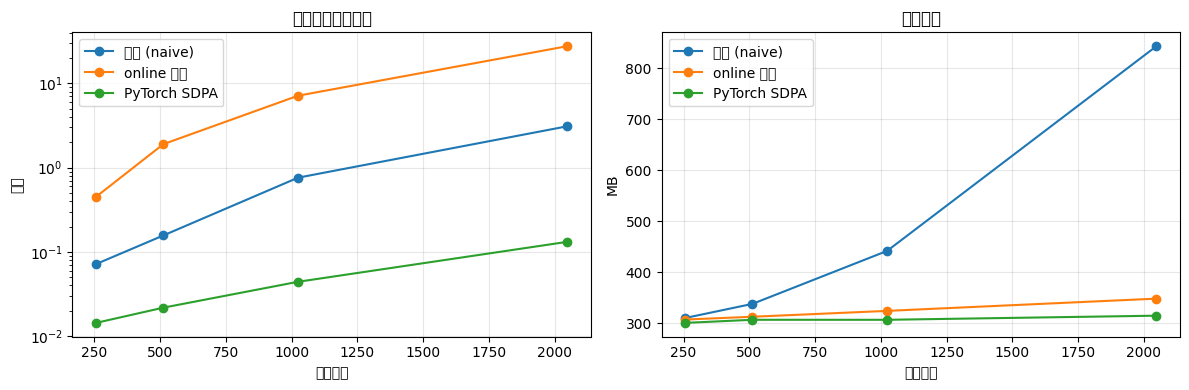

序列=2048 时：online 显存 349MB，确实远低于朴素的 843MB；
但 online 延迟 27.7ms，反而比朴素的 3.1ms 还慢，更被 SDPA 甩开一大截。


In [7]:
seqlens = [256, 512, 1024, 2048]
res = {"朴素 (naive)": ([], []), "online 分块": ([], []), "PyTorch SDPA": ([], [])}

for S in seqlens:
    q, k, v = make_qkv(2, 8, S, 64, dtype=torch.float16, seed=0)
    runs = [("朴素 (naive)",  lambda: naive_attention(q, k, v, causal=True), 3, 10),
            ("online 分块",   lambda: online_softmax_attention(q, k, v, causal=True), 1, 3),
            ("PyTorch SDPA",  lambda: F.scaled_dot_product_attention(q, k, v, is_causal=True), 10, 50)]
    for name, fn, warm, rep in runs:
        torch.cuda.reset_peak_memory_stats()
        res[name][0].append(bench_ms(fn, warmup=warm, rep=rep))
        res[name][1].append(peak_memory_mb())
    del q, k, v; torch.cuda.empty_cache()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
for name in res:
    ax1.plot(seqlens, res[name][0], "o-", label=name)
    ax2.plot(seqlens, res[name][1], "o-", label=name)
ax1.set(title="延迟（越低越好）", xlabel="序列长度", ylabel="毫秒"); ax1.set_yscale("log")
ax2.set(title="峰值显存", xlabel="序列长度", ylabel="MB")
for ax in (ax1, ax2): ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

i = seqlens.index(2048)
print(f"序列=2048 时：online 显存 {res['online 分块'][1][i]:.0f}MB，确实远低于朴素的 {res['朴素 (naive)'][1][i]:.0f}MB；")
print(f"但 online 延迟 {res['online 分块'][0][i]:.1f}ms，反而比朴素的 {res['朴素 (naive)'][0][i]:.1f}ms 还慢，更被 SDPA 甩开一大截。")


## 谜底：好算法 + 坏执行 = 慢

显存确实降下来了（左图 online 那条线贴着底走），可延迟却惨不忍睹。为什么？

因为我们的 online 分块是**纯 Python 的双重循环**：每处理一块，数据就在 GPU 高速缓存（SRAM）和
大显存（HBM）之间来回搬一趟，Python 解释器还要在旁边一圈圈空转。算法省下的功夫，全被这些
来回搬运和解释开销吃掉了。

反观 `SDPA` 那条线——又快又省。它的秘密是把整套 online softmax **焊死在一个 GPU kernel 里**：
打分、softmax、加权平均一气呵成，中间结果**从不离开 SRAM**，也就没有反复搬运。

> **这正是 FlashAttention 的起点。** 算法我们已经在这一章亲手推导出来了；
> 真正的功夫，在于怎么把它写成一个高效的 kernel。

**下一站** → [02-flash-attention](../02-flash-attention/)：我们拆开 triton 官方的 FlashAttention kernel，
一个模块一个模块地看，它是怎么把今天这套 online softmax 真正塞进 GPU 的。
